In [1]:
from nemo.collections.tts.models import MagpieTTSModel
from nemo.collections.tts.data.text_to_speech_dataset import MagpieTTSDataset, DatasetSample
from omegaconf.omegaconf import OmegaConf, open_dict
import torch
import os
import soundfile as sf
from IPython.display import display, Audio
import numpy as np
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

[NeMo W 2025-09-05 18:35:13 nemo_logging:405] /usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
      from .autonotebook import tqdm as notebook_tqdm
    
[NeMo W 2025-09-05 18:35:15 nemo_logging:405] /opt/megatron-lm/megatron/core/transformer/cuda_graphs.py:741: SyntaxWarning: assertion is always true, perhaps remove parentheses?
      assert (
    
[NeMo W 2025-09-05 18:35:16 nemo_logging:405] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.


### Checkpoint Paths

In [2]:

#######################################################################################################################################################
hparams_file = "/data/hparams.yaml"
checkpoint_file = "/data/magpieTTS--val_loss=9.4180-epoch=169-last.ckpt"

# codecmodel_path = "/datap/misc/checkpoints/AudioCodec_21Hz_no_eliz.nemo"
codecmodel_path = "/data/21fps_causal_codecmodel.nemo"


# Temp out dir for saving audios
out_dir = "/data/output_samples"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

### Load Model

In [3]:
model_cfg = OmegaConf.load(hparams_file).cfg

with open_dict(model_cfg):
    model_cfg.codecmodel_path = codecmodel_path
    if hasattr(model_cfg, 'text_tokenizer'):
        # Backward compatibility for models trained with absolute paths in text_tokenizer
        model_cfg.text_tokenizer.g2p.phoneme_dict = "scripts/tts_dataset_files/ipa_cmudict-0.7b_nv23.01.txt"
        model_cfg.text_tokenizer.g2p.heteronyms = "scripts/tts_dataset_files/heteronyms-052722"
        model_cfg.text_tokenizer.g2p.phoneme_probability = 1.0
    model_cfg.train_ds = None
    model_cfg.validation_ds = None


model = MagpieTTSModel(cfg=model_cfg)
print("Loading weights from checkpoint")
ckpt = torch.load(checkpoint_file, weights_only=False)
model.load_state_dict(ckpt['state_dict'])
print("Loaded weights.")

model.use_kv_cache_for_inference = True

model.cuda()
model.eval()

[NeMo W 2025-09-05 18:35:48 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    dataset:
      dataset_type: tarred_vocoder
      dataset_args:
        dataset_meta:
          mls_english:
            manifest_path: /lustre/fsw/portfolios/llmservice/projects/llmservice_nemo_speechlm/data/TTS/mls_english/filtered_22khz/tarred_audio/train_manifest.json
            tar_filepath: /lustre/fsw/portfolios/llmservice/projects/llmservice_nemo_speechlm/data/TTS/mls_english/filtered_22khz/tarred_audio/audio_{0..1999}.tar
          cv:
            manifest_path: /lustre/fsw/portfolios/llmservice/projects/llmservice_nemo_speechlm/data/TTS/commonvoice13/22khz/tarred_audio/train_manifest.json
            tar_filepath: /lustre/fsw/portfolios/llmservice/projects/llmservice_nemo_speechlm/data/TTS/commonvoice13/22khz/tarred_audio/audio_{0..279}.tar

[NeMo I 2025-09-05 18:35:48 nemo_logging:393] Vector quantizer does not support commit loss.
[NeMo I 2025-09-05 18:35:52 nemo_logging:393] PADDING: 1
[NeMo I 2025-09-05 18:35:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-09-05 18:35:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-09-05 18:35:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-09-05 18:35:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-09-05 18:35:56 nemo_logging:393] PADDING: 1
Speaker encoder loaded and frozen !!
[NeMo I 2025-09-05 18:36:01 nemo_logging:393] Model AudioCodecModel was successfully restored from /data/21fps_causal_codecmodel.nemo.


[NeMo W 2025-09-05 18:36:01 nemo_logging:405] `<class 'nemo.collections.tts.g2p.models.i18n_ipa.IpaG2p'>` is experimental and not ready for production yet. Use at your own risk.
[NeMo W 2025-09-05 18:36:01 nemo_logging:405] apply_to_oov_word=None, This means that some of words will remain unchanged if they are not handled by any of the rules in self.parse_one_word(). This may be intended if phonemes and chars are both valid inputs, otherwise, you may see unexpected deletions in your input.
[NeMo W 2025-09-05 18:36:01 nemo_logging:405] `<class 'nemo.collections.common.tokenizers.text_to_speech.tts_tokenizers.IPATokenizer'>` is experimental and not ready for production yet. Use at your own risk.
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should o

[NeMo I 2025-09-05 18:36:04 nemo_logging:393] Local transformer type: autoregressive
Loading weights from checkpoint
Loaded weights.


MagpieTTSModel(
  (context_text_embedding): Embedding(32000, 768)
  (_codec_model): AudioCodecModel(
    (audio_encoder): HiFiGANEncoder(
      (pre_conv): Conv1dNorm(
        (conv): ParametrizedConv1d(
          1, 24, kernel_size=(7,), stride=(1,), padding=(3,), padding_mode=replicate
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
        (activation): Identity()
      )
      (activations): ModuleList(
        (0-4): 5 x CodecActivation(
          (activation): LeakyReLU(negative_slope=0.01)
        )
      )
      (down_sample_conv_layers): ModuleList(
        (0): Conv1dNorm(
          (conv): ParametrizedConv1d(
            24, 48, kernel_size=(4,), stride=(2,), padding=(1,), padding_mode=replicate
            (parametrizations): ModuleDict(
              (weight): ParametrizationList(
                (0): _WeightNorm()
              )
            )
          )
          (a

### Initialize Dataset class and helper functions

In [4]:
test_dataset = MagpieTTSDataset(
    dataset_meta={},
    sample_rate=22050, #model_cfg.sample_rate,
    min_duration=0.5,
    max_duration=20,
    codec_model_samples_per_frame=model.codec_model_samples_per_frame,
    bos_id=model.bos_id,
    eos_id=model.eos_id,
    context_audio_bos_id=model.context_audio_bos_id,
    context_audio_eos_id=model.context_audio_eos_id,
    audio_bos_id=model.audio_bos_id,
    audio_eos_id=model.audio_eos_id,
    num_audio_codebooks=model.num_audio_codebooks,
    prior_scaling_factor=None,
    load_cached_codes_if_available=False,
    dataset_type='test',
    tokenizer_config=None,
    load_16khz_audio=model.model_type == 'single_encoder_sv_tts',
    use_text_conditioning_tokenizer=model.use_text_conditioning_encoder,
    pad_context_text_to_max_duration=model.pad_context_text_to_max_duration,
    context_duration_min=model.cfg.get('context_duration_min', 5.0),
    context_duration_max=model.cfg.get('context_duration_min', 5.0),
)
#test_dataset.text_tokenizer, test_dataset.text_conditioning_tokenizer = model.setup_tokenizers(model.cfg, mode='test')
test_dataset.text_tokenizer = model.tokenizer
test_dataset.text_conditioning_tokenizer = model.text_conditioning_tokenizer


def get_audio_duration(file_path):
    with sf.SoundFile(file_path) as audio_file:
        # Calculate the duration
        duration = len(audio_file) / audio_file.samplerate
        return duration

def create_record(text, context_audio_filepath=None, context_text=None):
    dummy_audio_fp = os.path.join(out_dir, "dummy_audio.wav")
    dummy_audio = sf.write(dummy_audio_fp, np.zeros(22050 * 3), 22050)  # 3 seconds of silence
    record = {
        'audio_filepath' : dummy_audio_fp,
        'duration': 3.0,
        'text': text,
        'speaker': "dummy",
    }
    if context_text is not None:
        assert context_audio_filepath is None
        record['context_text'] = context_text
    else:
        assert context_audio_filepath is not None
        record['context_audio_filepath'] = context_audio_filepath
        record['context_audio_duration'] = get_audio_duration(context_audio_filepath)
    
    return record

### Set transcript and context pairs to test

In [17]:
# Change sample text and prompt audio/text here
audio_base_dir = "/"
#zh_siwei = "/home/lustre/fs12/portfolios/edgeai/users/mdesta/utils/SIWEI_RETAIL_00001.wav"

#In different countries, there are different requirements for an individual to legally practice neurosurgery, and there are varying methods through which they must be educated.
test_entries = [

    create_record(
        text="I am going to repeat your order. It will be ready in ten minutes, please make sure to check the ingredients before eating.",
        context_text="Speaker and Emotion: | Language:en Dataset:RivaTTS Speaker:Sean | Emotion:Additional |",
    ),

]

data_samples = []
for entry in test_entries:
    dataset_sample = DatasetSample(
        dataset_name="sample",
        manifest_entry=entry,
        audio_dir=audio_base_dir,
        feature_dir=audio_base_dir,
        text=entry['text'],
        speaker=None,
        speaker_index=0,
        tokenizer_names=["english_phoneme"], # Change this for multilingual: "english_phoneme", "spanish_phoneme", "english_chartokenizer", "french_chartokenizer".. 
    )
    data_samples.append(dataset_sample)
    
test_dataset.data_samples = data_samples

test_data_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1,
    collate_fn=test_dataset.collate_fn,
    num_workers=0,
    shuffle=False
)

In [6]:
#display(Audio(zh_random_sample_2))

### Generate With Prior

### **Below cell can be skipped. This was from the original t5_tts inference notebook, and was a dummy cell to adjust parameters.**

Using provided speaking rate: tensor([1.], device='cuda:0')
Decoding timestep 0
Decoding timestep 20
Decoding timestep 40
Decoding timestep 60
End detected for item 0 at timestep 65
All ends reached
You ordered a burger, fries, salad, and sauce on the side.
Prior Used? True
Prior Used? True


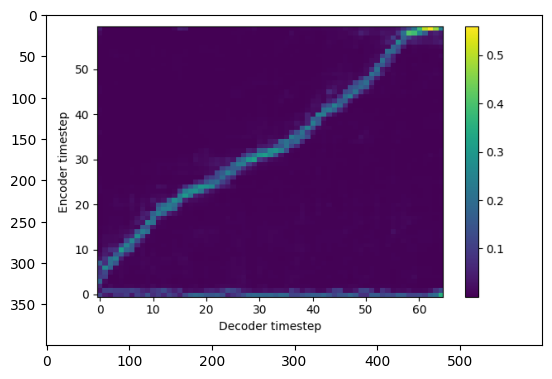

------------------------------------
------------------------------------


In [6]:
import matplotlib.pyplot as plt
#model.use_text_conditioning_encoder = True
item_idx = 0

# Define speaking rates to test
speaking_rates = [-0.8, 0, 0.8]  # Slow, Normal, Fast
speaking_rate_labels = ["Slow", "Normal", "Fast"]

for bidx, batch in enumerate(test_data_loader):
  
    #print("Processing batch {} out of {}".format(bidx, len(test_data_loader)))
    model.decoder.reset_cache(use_cache=True)
    batch_cuda ={}
    for key in batch:
        if isinstance(batch[key], torch.Tensor):
            batch_cuda[key] = batch[key].cuda()
        else:
            batch_cuda[key] = batch[key]
    import time
    st = time.time()

    for apply_prior in [True]:
        # predicted_audio, predicted_audio_lens, _, _, all_heads_attn_np, cross_attn_np, xall_heads = model.infer_batch(
        #     batch_cuda, 
        #     max_decoder_steps=440, 
        #     temperature=0.7, 
        #     topk=80, 
        #     use_cfg=False,
        #     cfg_scale=2.5,
        #     prior_epsilon=0.1,
        #     lookahead_window_size=5,
        #     return_cross_attn_probs=True,
        #     estimate_alignment_from_layers=[5,6,7],
        #     apply_attention_prior=apply_prior,
        #     apply_prior_to_layers=[0,1,2,3,4,5,6,7,8,9,10,11],
        #     compute_all_heads_attn_maps=True,
        #     use_local_transformer_for_inference=False,
        #     maskgit_n_steps=3,
        #     start_prior_after_n_audio_steps=0,
        #     speaking_rate=0.8
        # )
        predicted_audio, predicted_audio_lens, _, _, all_heads_attn_np, cross_attn_np, xall_heads = model.infer_batch(
            batch_cuda, 
            max_decoder_steps=440, 
            temperature=0.7, 
            topk=80, 
            use_cfg=False, # set use cfg to false
            cfg_scale=2.5,
            prior_epsilon=0.1,
            lookahead_window_size=5,
            return_cross_attn_probs=True,
            estimate_alignment_from_layers=[5,6,7],
            apply_attention_prior=apply_prior,
            apply_prior_to_layers=[0,1,2,3,4,5,6,7,8,9,10,11],
            compute_all_heads_attn_maps=True,
            use_local_transformer_for_inference=False,
            maskgit_n_steps=3,
            start_prior_after_n_audio_steps=0,
            speaking_rate=1
        )
        
        for idx in range(predicted_audio.size(0)):
            predicted_audio_np = predicted_audio[idx].float().detach().cpu().numpy()
            predicted_audio_np = predicted_audio_np[:predicted_audio_lens[idx]]
            audio_path = os.path.join(out_dir, f"predicted_audio_{item_idx}.wav")
            sf.write(audio_path, predicted_audio_np, 22050)
            print(test_entries[bidx]['text'])
            print("Prior Used?", apply_prior)
            print("Prior Used?", apply_prior)
            #print("use_local_transformer", use_local_transformer_for_inference)
            display(Audio(audio_path))
            item_idx += 1
            plt.imshow(cross_attn_np[idx])
            plt.show()
            print_all_layers = False
            if print_all_layers==True:
                for hidx, head_cross_attn in enumerate(xall_heads[idx]):
                    layer_num = hidx // model.cfg.decoder.xa_n_heads
                    head_num = hidx % model.cfg.decoder.xa_n_heads
                    print("item, layer, head", idx, layer_num, head_num)
                    plt.imshow(xall_heads[idx][hidx])
                    plt.show()
                
        print("------------------------------------")
        print("------------------------------------")

## **Generate with Prior**

### **Below cell is for doing inference with model that learned speaking rate "bins" from architecture changes. Model enhancement was conditioning text encoder input on speaking rate.** 

### Use the relevant speaking_rates map to define the speaking rate buckets and x-slow through x-fast for each speaker accordingly.


===== Processing: "I am going to repeat your order. It will be ready in ten minutes, please make sure to check the ingredients before eating." =====

Using provided speaking rate: tensor([-0.8000], device='cuda:0')
Decoding timestep 0
Decoding timestep 20
Decoding timestep 40
Decoding timestep 60
Decoding timestep 80
Decoding timestep 100
Decoding timestep 120
Decoding timestep 140
Decoding timestep 160
Decoding timestep 180
Decoding timestep 200
Decoding timestep 220
End detected for item 0 at timestep 225
All ends reached

🔊 Speaking Rate: x-slow (value: -0.8)
⏱️ Duration: 10.45 seconds


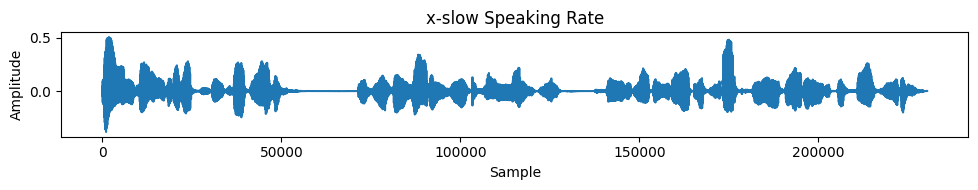

------------------------------------
Using provided speaking rate: tensor([-0.1000], device='cuda:0')
Decoding timestep 0
Decoding timestep 20
Decoding timestep 40
Decoding timestep 60
Decoding timestep 80
Decoding timestep 100
Decoding timestep 120
Decoding timestep 140
Decoding timestep 160
Decoding timestep 180
End detected for item 0 at timestep 194
All ends reached

🔊 Speaking Rate: slower (value: -0.1)
⏱️ Duration: 9.01 seconds


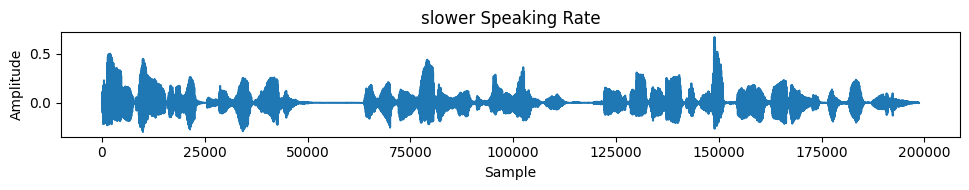

------------------------------------
Using provided speaking rate: tensor([0.5000], device='cuda:0')
Decoding timestep 0
Decoding timestep 20
Decoding timestep 40
Decoding timestep 60
Decoding timestep 80
Decoding timestep 100
Decoding timestep 120
Decoding timestep 140
Decoding timestep 160
End detected for item 0 at timestep 167
All ends reached

🔊 Speaking Rate: Normal (value: 0.5)
⏱️ Duration: 7.76 seconds


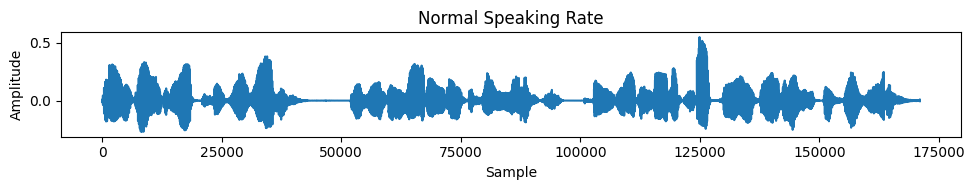

------------------------------------
Using provided speaking rate: tensor([0.7700], device='cuda:0')
Decoding timestep 0
Decoding timestep 20
Decoding timestep 40
Decoding timestep 60
Decoding timestep 80
Decoding timestep 100
Decoding timestep 120
Decoding timestep 140
End detected for item 0 at timestep 147
All ends reached

🔊 Speaking Rate: faster (value: 0.8)
⏱️ Duration: 6.83 seconds


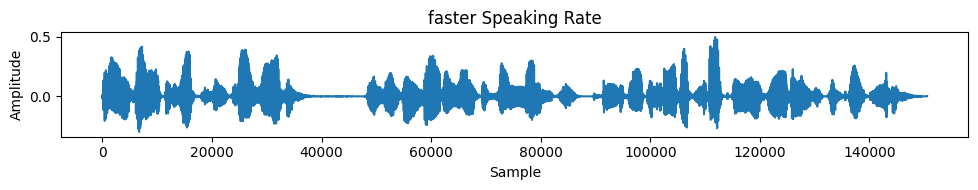

------------------------------------
Using provided speaking rate: tensor([1.], device='cuda:0')
Decoding timestep 0
Decoding timestep 20
Decoding timestep 40
Decoding timestep 60
Decoding timestep 80
Decoding timestep 100
End detected for item 0 at timestep 106
All ends reached

🔊 Speaking Rate: x-fast (value: 1.0)
⏱️ Duration: 4.92 seconds


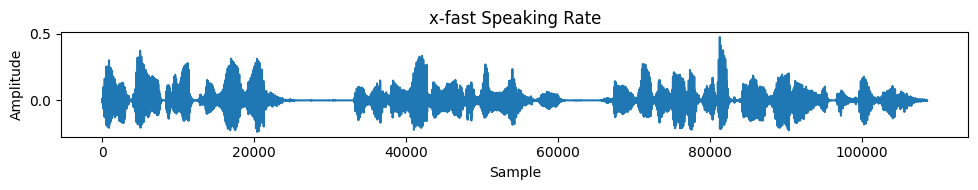

------------------------------------

📊 Results Summary:
+----------------------------------------------------------------------------------------------------------------------------+-----------------+--------------+------------------+
| Text                                                                                                                       | Speaking Rate   |   Rate Value |   Duration (sec) |
+============================================================================================================================+=================+==============+==================+
| I am going to repeat your order. It will be ready in ten minutes, please make sure to check the ingredients before eating. | x-slow          |         -0.8 |            10.45 |
+----------------------------------------------------------------------------------------------------------------------------+-----------------+--------------+------------------+
| I am going to repeat your order. It will be re

In [18]:
import matplotlib.pyplot as plt
import os
import time
import numpy as np
from IPython.display import Audio, display
import soundfile as sf

speaking_rates = {
   "x-slow": -0.8,
   "slower": -0.1,
   "Normal": 0.5,
   "faster": 0.77,
   "x-fast": 1.0
}


# Example: For Sean, below are some of the speaking rate bins and their "rates" I defined after testing different parameters
# Below parameters include x-slow and x-fast, for inference during "hybrid" approach with architecture change + injected x-fast, x-slow data
# speaking_rates = {
#    "x-slow": -0.8,
#    "slower": -0.1,
#    "Normal": 0.5,
#    "faster": 0.77,
#    "x-fast": 1.0
# }

# Please note, depending on how short vs long the utterance is, sometimes the best speaking rate definition for slow, normal, fast, etc can change


# Example: For Emma, below are some of the speaking rate bins and their "rates" I defined after testing different parameters
# Below parameters include x-slow and x-fast, for inference during "hybrid" approach with architecture change + injected x-fast, x-slow data
# speaking_rates = {
#     "x-slow": -0.5,
#     "slower": 0.0,
#     "Normal": 0.5,
#     "faster": 0.9,
#     "x-fast": 1.0
# }


# For model trained with only existing data Riva Speaker data, x-slow, x-fast not supported very well.
#Below are some parameters found for inference, from experimentation. Please note, these might need further adjustment.

# Shorter utterances for Sean & Emma
# speaking_rates = {
#     "slower": -0.9,
#     "Normal": 0.2,
#     "fast": 1.0
# }

# Note that, mainly the  "slow" parameter is different for these 

# Longer utterances for Sean
# speaking_rates = {
#     "slower": -0.3,
#     "Normal": 0.5,
#     "fast": 1.0
# }

# Longer utterances for Emma
# speaking_rates = {
#     "slower": -0.6,
#     "Normal": 0.5,
#     "fast": 1.0
# }

# Longer utterances for Megan
# speaking_rates = {
#     "slower": -0.4,
#     "Normal": 0.5,
#     "fast": 1.0
# }

# Longer utterances for Lindy
# speaking_rates = {
#     "slower": -0.8,
#     "Normal": 0.4,
#     "fast": 1.0
# }




# Create a results table
results_table = []
apply_prior = True
item_idx = 0
for bidx, batch in enumerate(test_data_loader):
    model.decoder.reset_cache(use_cache=True)
    batch_cuda = {}
    for key in batch:
        if isinstance(batch[key], torch.Tensor):
            batch_cuda[key] = batch[key].cuda()
        else:
            batch_cuda[key] = batch[key]
    
    # Get the text for display
    text = test_entries[bidx]['text']
    print(f"\n===== Processing: \"{text}\" =====\n")
    
    # Generate speech at different speaking rates
    for rate_name, rate_value in speaking_rates.items():
        st = time.time()
        predicted_audio, predicted_audio_lens, _, _, all_heads_attn_np, cross_attn_np, xall_heads = model.infer_batch(
            batch_cuda, 
            max_decoder_steps=440, 
            temperature=0.7, 
            topk=80, 
            use_cfg=True, # set use cfg to false
            cfg_scale=2.5,
            prior_epsilon=0.1,
            lookahead_window_size=5,
            return_cross_attn_probs=True,
            estimate_alignment_from_layers=[5,6,7],
            apply_attention_prior=apply_prior,
            apply_prior_to_layers=[0,1,2,3,4,5,6,7,8,9,10,11],
            compute_all_heads_attn_maps=True,
            use_local_transformer_for_inference=False,
            maskgit_n_steps=3,
            start_prior_after_n_audio_steps=0,
            speaking_rate=rate_value
        )
        
        gen_time = time.time() - st
        
        for idx in range(predicted_audio.size(0)):
            predicted_audio_np = predicted_audio[idx].float().detach().cpu().numpy()
            predicted_audio_np = predicted_audio_np[:predicted_audio_lens[idx]]
            
            # Calculate duration
            duration = len(predicted_audio_np) / model.sample_rate
            
            # Include speaking rate in filename
            audio_path = os.path.join(out_dir, f"audio_{item_idx}_{rate_name.replace(' ', '_')}.wav")
            sf.write(audio_path, predicted_audio_np, model.sample_rate)
            
            # Store results for table
            results_table.append({
                "Text": text,
                "Speaking Rate": rate_name,
                "Rate Value": f"{rate_value:.1f}",
                "Duration (sec)": f"{duration:.2f}"
            })
            
            print(f"\n🔊 Speaking Rate: {rate_name} (value: {rate_value:.1f})")
            print(f"⏱️ Duration: {duration:.2f} seconds")
            
            # Display audio
            display(Audio(audio_path))
            
            # Plot waveform for visual comparison
            plt.figure(figsize=(10, 2))
            plt.plot(predicted_audio_np)
            plt.title(f"{rate_name} Speaking Rate")
            plt.xlabel("Sample")
            plt.ylabel("Amplitude")
            plt.tight_layout()
            plt.show()
                
        print("------------------------------------")
    
    # Display results table after processing each text
    try:
        from tabulate import tabulate
        headers = ["Text", "Speaking Rate", "Rate Value", "Duration (sec)"]
        table_data = [[r["Text"], r["Speaking Rate"], r["Rate Value"], r["Duration (sec)"]] 
                      for r in results_table if r["Text"] == text]
        print("\n📊 Results Summary:")
        print(tabulate(table_data, headers=headers, tablefmt="grid"))
    except ImportError:
        # Fallback if tabulate is not available
        print("\n📊 Results Summary:")
        for r in [r for r in results_table if r["Text"] == text]:
            print(f"- {r['Speaking Rate']} (value: {r['Rate Value']}): Duration = {r['Duration (sec)']}s")
    
    # Calculate and display speed differences for this text
    normal_duration = float([r["Duration (sec)"] for r in results_table 
                            if r["Text"] == text and r["Speaking Rate"] == "Normal"][0])
    
    print("\n🔄 Speaking Rate Effect:")
    for r in [r for r in results_table if r["Text"] == text]:
        duration = float(r["Duration (sec)"])
        pct_change = ((duration - normal_duration) / normal_duration) * 100
        change_str = f"{pct_change:+.1f}% compared to Normal"
        if pct_change < 0:
            change_str += " (faster)"
        elif pct_change > 0:
            change_str += " (slower)"
        print(f"- {r['Speaking Rate']}: {duration:.2f}s ({change_str})")
    
    print("\n")
    
    item_idx += 1
    if item_idx >= 2:  # Limit to 2 examples
        break

# Display final comprehensive results table
print("\n===== 📝 FINAL RESULTS =====\n")
try:
    from tabulate import tabulate
    headers = ["Text", "Speaking Rate", "Rate Value", "Duration (sec)"]
    table_data = [[r["Text"], r["Speaking Rate"], r["Rate Value"], r["Duration (sec)"]] 
                  for r in results_table]
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
except ImportError:
    print("Install tabulate for better formatted tables")
    for r in results_table:
        print(f"- {r['Text']} | {r['Speaking Rate']} | Duration: {r['Duration (sec)']}s")

# Save a summary CSV file
try:
    import csv
    with open(os.path.join(out_dir, "speaking_rate_results.csv"), "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["Text", "Speaking Rate", "Rate Value", "Duration (sec)"])
        writer.writeheader()
        writer.writerows(results_table)
    print(f"\nResults saved to {os.path.join(out_dir, 'speaking_rate_results.csv')}")
except:
    print("Could not save CSV file")
